In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import clear_output
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from scipy.stats import norm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn import svm
import math
import warnings
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

    cont-src-1  cont-src-2  radiation-reading  source
2     0.731024    0.733000       7.710875e-16    file
7     0.683418    0.861057       2.535001e-40    file
1     0.574329    0.879898       1.033078e-46    file
9     0.883890    0.582254       6.229856e-48    file
0     0.319404    0.762959       1.322677e-79    file
8     0.082507    0.403488       3.606771e-81    file
3     0.840353    0.264732      3.341771e-124    file
12    0.579291    1.059596      4.507438e-133  week-3
11    0.404040    0.959596     -9.343448e-112  week-2
6     0.312691    0.078723      -2.089093e-91    file
13    0.436769    0.825163      -1.519972e-55  week-4
5     0.410437    0.147554      -2.159249e-54    file
10    0.848485    0.777778      -1.248783e-49  week-1
4     0.650114    0.681526      -3.606063e-03    file


/var/folders/d6/s3jc1rb17y1411yjy8r6jlf80000gn/T/ipykernel_49961/923837372.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('tab10', len(other_cols))


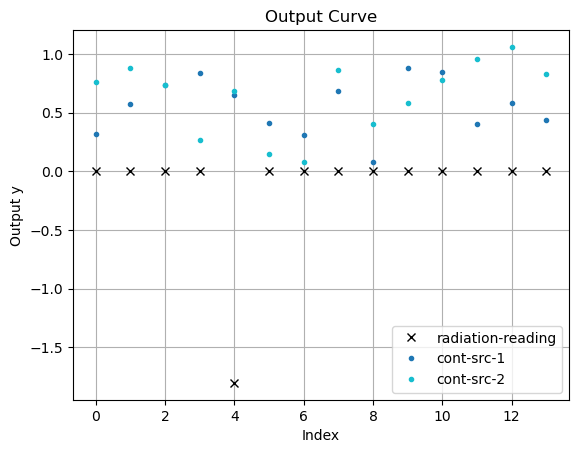

In [2]:
#Process data
%run data_handler.ipynb

In [3]:
X = inputs
y = outputs

In [4]:
%run ../common_functions.ipynb
# Initialize result collection
query_results = []


In [5]:
def sweep_hyperparameters_fixedNN(X, y,
                                   xi_values=[0.01, 0.1, 0.3],
                                   kappa_values=[1.0, 2.0, 5.0],
                                   grid_sizes=[50, 75, 100],
                                   methods=['PI', 'EI', 'UCB'],
                                   apply_scaling=False,
                                   filter_mode='gp'):
    # Clear global query_results at the start
    global query_results
    query_results = []

    for method in methods:
        if method in ['PI', 'EI']:
            for xi in xi_values:
                for grid_size in grid_sizes:
                    next_query, acq_map, _ = select_next_query_multi_fixedNN(
                        X, y, method=method, xi=xi, grid_size=grid_size,
                        apply_scaling=apply_scaling, filter_mode=filter_mode
                    )
                    if next_query is None or acq_map is None:
                        print(f"⚠️ Skipping config: method={method}, xi={xi}, grid_size={grid_size}")
                        continue
                    score = np.max(acq_map)
                    log_query_candidate(method, xi, next_query, score)

        elif method == 'UCB':
            for kappa in kappa_values:
                for grid_size in grid_sizes:
                    next_query, acq_map, _ = select_next_query_multi_fixedNN(
                        X, y, method=method, kappa=kappa, grid_size=grid_size,
                        apply_scaling=apply_scaling, filter_mode=filter_mode
                    )
                    if next_query is None or acq_map is None:
                        print(f"⚠️ Skipping config: method={method}, kappa={kappa}, grid_size={grid_size}")
                        continue
                    score = np.max(acq_map)
                    log_query_candidate(method, kappa, next_query, score)

    if not query_results:
        raise RuntimeError("No valid configurations found during sweep.")

    best = find_best_candidate(query_results)
    return best, query_results

In [6]:
best, query_results = sweep_hyperparameters_fixedNN(X, y, filter_mode='gp')

Input space dimension: 2
Computing bounds with margin 0.1.
Bounds per feature: [(-0.017492748179194134, 0.983889828818117), (-0.02127722205028118, 1.159596)]
Creating 50^(2) grid.
Grid shape: (2500, 2)
Points before downsampling: 2500
Filtering grid using mode: gp
Grid shape before filtering: (2500, 2)
Filtered 0 candidates near decision boundary (|margin| < 0.2)
Excluded 2500 candidates from consideration
Final grid shape: (0, 2)
Filtered grid shape: (0, 2)
Final grid shape: (0, 2)
⚠️ Warning: SVM filter removed all grid points. Skipping this configuration.
⚠️ Skipping config: method=PI, xi=0.01, grid_size=50
Input space dimension: 2
Computing bounds with margin 0.1.
Bounds per feature: [(-0.017492748179194134, 0.983889828818117), (-0.02127722205028118, 1.159596)]
Creating 75^(2) grid.
Grid shape: (5625, 2)
Points before downsampling: 5625
Filtering grid using mode: gp
Grid shape before filtering: (5625, 2)
Filtered 136 candidates near decision boundary (|margin| < 0.2)
Excluded 5489 

In [7]:
print("Best Hyperparameter Configuration:")
print(best)

Best Hyperparameter Configuration:
{'method': 'PI', 'xi': 0.01, 'kappa': None, 'x': array([0.66021061, 0.94489178]), 'score': 0.9999986997470562, 'dim': 2}


In [8]:
#add points to dataframe
#print(df)
add_points_to_df(df_sorted, query_results)
pd.set_option('display.max_rows', None)
print(df_sorted)

    cont-src-1  cont-src-2  radiation-reading  source
2     0.731024    0.733000       7.710875e-16    file
7     0.683418    0.861057       2.535001e-40    file
1     0.574329    0.879898       1.033078e-46    file
9     0.883890    0.582254       6.229856e-48    file
0     0.319404    0.762959       1.322677e-79    file
8     0.082507    0.403488       3.606771e-81    file
3     0.840353    0.264732      3.341771e-124    file
12    0.579291    1.059596      4.507438e-133  week-3
11    0.404040    0.959596     -9.343448e-112  week-2
6     0.312691    0.078723      -2.089093e-91    file
13    0.436769    0.825163      -1.519972e-55  week-4
5     0.410437    0.147554      -2.159249e-54    file
10    0.848485    0.777778      -1.248783e-49  week-1
4     0.650114    0.681526      -3.606063e-03    file
14    0.591456    0.952145                NaN  week-x
15    0.660211    0.944892                NaN  week-x
16    0.388473    0.920230                NaN  week-x
17    0.457911    1.052244  

/var/folders/d6/s3jc1rb17y1411yjy8r6jlf80000gn/T/ipykernel_49961/923837372.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('tab10', len(other_cols))


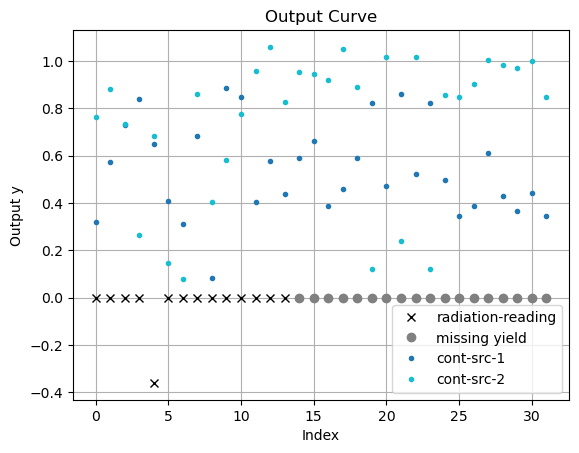

In [9]:
plot_output_points(df_sorted, scale_factor=1.0, yield_scale_factor=100.0, nan_marker='o')

In [10]:
candidates, labels = extract_candidates_and_labels(query_results, include_score=True)

plot_surrogate_generic(X_grid_filtered, mean, 
                       X_filtered=X_grid_filtered, bounds=bounds, candidates=candidates, candidate_labels=None,
                       title="GP")

NameError: name 'X_grid_filtered' is not defined